# Option analytics: pricing the cross-section instead of describing it

The three notebooks before this one share a shape. Estimate exposures, estimate factor returns,
multiply. [`11a_pca`](11a_pca.ipynb) took the exposures from the return panel,
[`11b_ipca`](11b_ipca.ipynb) made them a linear function of the characteristics, and
[`11c_conditional_autoencoder`](11c_conditional_autoencoder.ipynb) made that function a network.
All three answer the question *how does this cross-section move together*.

**The stochastic discount factor asks a different question, and the answer is not a factor
structure.** It asks what single random variable, multiplied into every asset's return, would make
them all price correctly - which is what no-arbitrage says must exist. Estimating that object
directly means there is no factor-return history to hand to a forecaster afterwards, so the
two-stage shape is not simplified here, it is absent.

**It is fitted adversarially, which is why the epoch schedule looks unlike its siblings'.** One
network proposes the discount factor; a second network constructs the portfolio that the first one
prices worst. Training alternates: the discount factor improves against the current adversary, the
adversary improves against the current discount factor. The configuration therefore declares three
separate budgets rather than one `n_epochs`, and the published checkpoint numbers are epochs of
two different phases packed onto one axis - section 1 sets out how.

**It is also the only member of this family that reads anything outside the cross-section.** The
adapter resolves a macro panel for `sdf` and for no other model, so the state variables the
discount factor is conditioned on include the macro environment as well as each stock's own option
surface.

**Learning objectives.** By the end of this notebook you will be able to:

- State what a stochastic discount factor is estimating, and why that is not a factor model.
- Explain what makes the training adversarial and what the three declared budgets do.
- Read a checkpoint column that packs two training phases onto one axis, where an unconditional
  epoch is published as itself and a conditional epoch as the unconditional budget plus itself.
- Say why the states the library picked by reading the validation split are computed and then
  discarded rather than published, and what would go wrong if one of them reached the population.

**Book reference**: Chapter 14, Section 14.6 (the stochastic discount factor and the adversarial
estimator of Chen, Pelger and Zhu, 2021). Chapter 6, Section 6.7 (Search accounting and run
logging) introduces the run log this notebook writes into.

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have written the feature matrices,
[`05_evaluation`](05_evaluation.ipynb) has established the walk-forward folds, and
[`11_latent_factors`](11_latent_factors.ipynb) introduces the family and says which of its five
members each notebook publishes.

**What it writes**: one training run per label and one complete validation prediction set per
label and checkpoint, in `run_log/registry.db` and under `run_log/training/` and
`run_log/predictions/`, grouped under a population named for this model. The family splits across
five notebooks, so each publishes its own population rather than one shared one.
[`13_model_analysis`](13_model_analysis.ipynb) compares them against the other families and
[`14_backtest`](14_backtest.ipynb) selects on validation backtest Sharpe. **Selection happens
there, not here.**

In [1]:
"""Fit the declared option-analytics SDF population on the walk-forward folds."""

import plotly.graph_objects as go
import polars as pl

from case_studies.research import (
    declared_labels,
    load_model_configs,
    model_requests,
    open_study,
    plan_models,
    planned_model_plan,
    primary_label,
    run_model_population,
)
from utils.style import COLORS, show_plotly_with_alt

In [2]:
LABELS: list[str] = []
EXECUTION_TIER = "canonical"
WORKSPACE: str = ""
PREVIEW_REDUCTIONS: dict = {}
POPULATION_NAME = ""
SUPERSEDES_POPULATION: str = ""
DEVICE: str = ""

MODEL_NAME = "sdf"

In [3]:
study = open_study(
    "sp500_equity_option_analytics",
    execution_tier=EXECUTION_TIER,
    workspace=WORKSPACE or None,
    entry_point="11d_stochastic_discount_factor",
)

## 1. Which labels, and what the configuration says

Every label whose training menu declares `latent_factors:` is fitted, and the cell below reads
which those are rather than this sentence asserting a count that would go stale the moment a
sixth label declared the family. What the names mean is the part prose has to supply:
`fwd_ret_5d` is the stock's total return over the five trading days after the decision date,
`fwd_ret_10d` the same over ten, and `fwd_ret_risk_adj_5d` the five-day return divided by a
measure of its own dispersion. A `fwd_dir_*` classification label declaring only linear and
gradient boosting is absent here rather than dropped.

In [4]:
declared_labels(study, "latent_factors")

('fwd_ret_10d', 'fwd_ret_5d', 'fwd_ret_risk_adj_5d')

### Three budgets, and one checkpoint axis across two phases

`case_studies/config/sdf/sdf.yaml` declares `n_epochs_unc: 256`, `n_epochs_moment: 64` and
`n_epochs_cond: 1024`. Training runs in phases: an unconditional phase in which the discount
factor is fitted against the whole cross-section, a moment phase in which the adversary is fitted,
and a conditional phase in which the discount factor is refitted with the state variables
available to it. `checkpoint_epochs: [256, 512, 768, 1024]` is applied **within each phase**.

The published checkpoint number is a single integer across both phases, so the library offsets
the conditional phase by the unconditional budget when it labels a checkpoint: conditional epoch
*e* is published as `256 + e`. The unconditional phase is
only 256 epochs long, so exactly one scheduled checkpoint falls inside it.

**The library also keeps four states per fit that are not epochs, and none of them is published.**
It captures, in each phase, the state with the lowest validation loss and the state with the
highest validation Sharpe. The same labelling maps those onto zero and the negative integers so
that two training phases fit on one axis, but the schedule that decides what gets
registered is built from the physical epochs alone, so the four are computed and discarded. Section
5 says why that is the right disposal and why the axis they were packed onto is still a trap.

`config/setup.yaml` restates `checkpoint_epochs` under `modeling.latent_factors.model_kwargs.sdf`
along with `beta_checkpoint_epochs` and `beta_default_checkpoint`, which govern the separate head
that turns the fitted discount factor into a per-stock signal.

In [5]:
configs = load_model_configs(
    study,
    "latent_factors",
    labels=LABELS or None,
    config_names=[MODEL_NAME],
)
configs

family,label,config_name,model_class,params
str,str,str,str,str
"""latent_factors""","""fwd_ret_10d""","""sdf""","""""","""n_factors=5"""
"""latent_factors""","""fwd_ret_5d""","""sdf""","""""","""n_factors=5"""
"""latent_factors""","""fwd_ret_risk_adj_5d""","""sdf""","""""","""n_factors=5"""


`LABELS` narrows what is fitted, and a narrowed run declares a different set of members than the
canonical population does. A population is immutable once written, so such a run must publish
under its own name: on a fresh workspace it would otherwise register an incomplete snapshot under
the canonical one, and where the full population already exists the registry refuses it.

The comparison is against this model's own declared rows rather than the whole `latent_factors`
catalog. The family is split across five notebooks and each publishes one model, so the complete
catalog is five times what this one publishes, and comparing against it would report every
canonical run as narrowed.

In [6]:
declared = load_model_configs(study, "latent_factors", config_names=[MODEL_NAME])
if set(configs.get_column("label")) != set(declared.get_column("label")) and not POPULATION_NAME:
    raise ValueError(
        f"this run fits {configs.height} of the {declared.height} declared labels, so it cannot "
        "publish the canonical population; pass POPULATION_NAME to give it its own"
    )

### The device, and the one input that comes from outside the cross-section

`config/setup.yaml` declares the latent-factor family on CUDA. That declaration exists because the
device sits inside the hashed computation rather than beside it as provenance: with no value
declared, the library falls back to whichever device the machine happens to have, and the training
identity becomes a property of the host. [`11a_pca`](11a_pca.ipynb) and
[`11b_ipca`](11b_ipca.ipynb) override it to `cpu` because their runners take no device at all;
this one is a torch model trained on the declared device, so it passes no override.

The adapter resolves a macro panel for `sdf` and refuses it for every other latent model
when the adapter resolves the request. Those macro values are hashed into the
request alongside the characteristics, so a run whose macro panel differs is a different training
identity rather than the same model on slightly different inputs.

A machine without a card cannot run the declared device at all, and the library refuses to
substitute one: the latent-factor runtime raises when CUDA is declared and unavailable rather
than falling back to the CPU, because a silent fallback changes what was fitted. `DEVICE` names the
device such a run fits on. It travels with `POPULATION_NAME`, because the device it names is
inside the training identity: the run computes a different member set and has to publish under
its own name rather than into the population the declaration describes.

In [7]:
overrides: dict = {"device": DEVICE} if DEVICE else {}
print(f"training device: {DEVICE or 'the family declaration in config/setup.yaml (cuda)'}")
print("macro context: resolved by the adapter for sdf, and hashed into the request")

training device: the family declaration in config/setup.yaml (cuda)
macro context: resolved by the adapter for sdf, and hashed into the request


## 2. Binding the declarations to the data

A menu entry names an estimator, a factor count and three epoch budgets. It does not say which
feature columns exist today, where the walk-forward folds fall, or which symbol-date pairs have
both a return and a label. **Planning** works all of that out - and every training and prediction
identity with it - without fitting anything. Four things to check:

- **`feature_count` and `eligible_rows` agree across the rows.** A row that differs is a label
  measured on a different sample from its neighbours. They differ *between* labels, because a
  ten-day forward window runs out earlier than a five-day one.
- **`folds` is the same everywhere**, and equals the number of walk-forward splits
  [`05_evaluation`](05_evaluation.ipynb) established.
- **`validation_start` and `validation_end` bracket the development sample**, with none of the
  held-out 2021 tail visible.
- **`checkpoints` is larger than the four entries `checkpoint_epochs` declares**, because both
  training phases draw from that one list and the conditional phase's epochs are published offset
  by the unconditional budget. Read it here rather than inferring it from the configuration.

In [8]:
requests = model_requests(
    study,
    configs,
    execution_tier=EXECUTION_TIER,
    overrides=overrides,
    preview_reductions=PREVIEW_REDUCTIONS,
)
plan = plan_models(study, requests=requests)

planned_model_plan(plan).select(
    "label",
    "config_name",
    "task",
    "feature_count",
    "eligible_rows",
    "folds",
    "checkpoints",
    "validation_start",
    "validation_end",
)

label,config_name,task,feature_count,eligible_rows,folds,checkpoints,validation_start,validation_end
str,str,str,i64,i64,i64,i64,str,str
"""fwd_ret_10d""","""sdf""","""regression""",48,192139,2,5,"""2019-01-07 00:00:00""","""2020-12-16 00:00:00"""
"""fwd_ret_5d""","""sdf""","""regression""",48,194813,2,5,"""2019-01-07 00:00:00""","""2020-12-23 00:00:00"""
"""fwd_ret_risk_adj_5d""","""sdf""","""regression""",48,194748,2,5,"""2019-01-07 00:00:00""","""2020-12-23 00:00:00"""


The plan is also where a short population is visible. A run that fitted fewer labels than the
menu declares would still print an IC table and still register its rows; what it would not do is
announce the gap.

In [9]:
planned_pairs = {(member.label, member.config_name) for member in plan.members}
requested_pairs = set(zip(configs["label"], configs["config_name"], strict=True))
if planned_pairs != requested_pairs:
    raise RuntimeError(
        "the plan does not match the loaded SDF menu; "
        f"missing {sorted(requested_pairs - planned_pairs)}, "
        f"unexpected {sorted(planned_pairs - requested_pairs)}"
    )
print(f"{len(requested_pairs)} label-configuration pairs")
print(f"{len(plan.expected_training_hashes)} training identities")
print(f"{len(plan.expected_prediction_hashes)} validation prediction sets")

3 label-configuration pairs
3 training identities
15 validation prediction sets


## 3. Fitting the population

`run_model_population` runs every planned request. For one request it walks the folds, and on
each one:

1. fits the discount-factor network on the training window against a fixed set of instruments -
   the unconditional phase,
2. fits the adversary network to find the portfolio the current discount factor misprices worst -
   the moment phase,
3. refits the discount factor against that adversary, with the state variables and the macro panel
   available to it - the conditional phase, capturing a state whenever the schedule says so,
4. fits a separate head that maps the fitted discount factor onto a per-stock signal, and applies
   it to the validation window's characteristics.

Step 4 is what makes the output comparable with the other four notebooks at all. The discount
factor itself is a portfolio weight, not a return forecast; the head is what turns it into a
number that can be ranked against a forward return. That translation is a modelling choice on top
of the estimator, and it is the reason an SDF row and a PCA row can sit in the same table.

**This notebook passes the plan rather than resolved requests, and on this family that changes
what the plan table can show rather than how the fitting is ordered.** The linear, boosted and
TabM adapters each provide a batch runner that prepares one fold set for several configurations;
the latent-factor adapter provides none, so every request is fitted on its own whichever path is
taken. There would be nothing to share in any case: this notebook publishes one model against
three labels, and each label is a different set of rows. What passing the plan costs is
`eligible_entities`, which needs the eligibility keys themselves; `eligible_rows` above moves
whenever the universe does, so the check that column existed for is still made.

**What the call publishes is a population**: a named, immutable list of the prediction sets it
will produce, written down before the first fit. Afterwards every member must exist and be
complete, which is what makes the downstream comparison well defined.

In [10]:
def catalog_labels(execution) -> int:
    """Number of distinct labels the execution published, read from its catalog rows."""
    return execution.catalog_rows.get_column("label").n_unique()


population_name = POPULATION_NAME or f"sp500_equity_option_analytics-{MODEL_NAME}-validation-v1"
execution, population = run_model_population(
    study, plan, population_name=population_name, supersedes=SUPERSEDES_POPULATION or None
)

# No per-fold counts: this family's runner reports none, and two zeros would read as a failed fit.
print(f"{len(execution.runs)} training runs across {catalog_labels(execution)} labels")
print(f"population {population.name}: {len(population.members)} prediction sets")

Latent factor CV: 1 models × 2 folds
Log file: case_studies/sp500_equity_option_analytics/run_log/training/4ceba900c397/.models.8143203502bc4a81b36d84e002321517.tmp/latent_factors.log
Scoring: dates=all cadence=- step=1 checkpoint_selection=fixed reporting_epoch=1280
  sdf (K=5):


    Fold 0: ragged train=475, val=251, max_N=503


      fold 0: reported_epoch=1280, IC=-0.0022, 609.9s


    Fold 1: ragged train=493, val=241, max_N=503


      fold 1: reported_epoch=1280, IC=-0.0085, 613.9s


...

      fold 0: reported_epoch=1280, IC=-0.0035, 384.0s


    Fold 1: ragged train=498, val=246, max_N=503


      fold 1: reported_epoch=1280, IC=-0.0007, 491.1s


    -> reporting epoch=1280 (fixed), IC=-0.0021 (889.6s)
  Best: sdf (IC=-0.0021)


3 training runs across 3 labels
population sp500_equity_option_analytics-sdf-validation-v1: 15 prediction sets


`reused` is not zero on a second run. Every identity is re-derived from the inputs, the registry
already holds the matching rows, and the runner returns the stored result rather than fitting
again - so re-running this notebook unchanged costs the time it takes to read the data.

### Running configurations of your own

The published run log is read-only. To add runs, open the study against a workspace, which holds
its own registry and artifacts and reads the same labels and features:

```python
study = open_study("sp500_equity_option_analytics", workspace="~/ml4t-experiments")
configs = load_model_configs(
    study, "latent_factors", labels=["fwd_ret_5d"], config_names=["sdf"]
)
requests = model_requests(study, configs)
plan = plan_models(study, requests=requests)
execution, population = run_model_population(study, plan, population_name="my-sdf-v1")
```

To change the budgets or the checkpoint schedule for your own run, edit
`case_studies/config/sdf/sdf.yaml`, or declare the value under
`modeling.latent_factors.model_kwargs.sdf` in `config/setup.yaml` to override the preset for this
case study alone - which is what this case study already does for `checkpoint_epochs`. Note which
of those you want: the preset is shared by every case study that declares `sdf`, so editing it
moves the training identity of all of them. Either way the result registers as a new row beside
the old one rather than replacing it.
[`RUN_LOG.md`](../RUN_LOG.md#running-your-own-configurations) covers the rest.

## 4. What came out

One row per label and checkpoint. The **information coefficient** is the rank correlation, on one
validation date, between the stocks ordered by the model's prediction and the stocks ordered by
the return they went on to earn.

`ic_mean` aggregates that **over folds, not over days**: each fold's own mean IC is computed and
those are averaged with equal weight (`latent_factors/cv.py`, and the convention is stated in
`registry/metrics.py`). With folds of unequal length the fold mean and the pooled daily mean are
different numbers, and this column is the first.

`ic_n_days` is how many validation dates produced a defined correlation, and it decides which rows
are comparable with each other. `auc_scored_against` says what the AUC column was scored against:
a regression row has no classes of its own and is scored as a ranking signal against a declared
direction sibling, so `fwd_ret_5d` is scored against `fwd_dir_5d` and `fwd_ret_10d` against
`fwd_dir_10d`. `fwd_ret_risk_adj_5d` declares no sibling and carries no AUC; null there means not
computed, not zero.

Every published `checkpoint_value` has to be a positive epoch, and the cell below refuses the
catalog if one is not. The four validation-chosen states are packed onto zero and the negative
integers, so a non-positive value here would mean one of them reached the registry - and it would
then compete, on validation IC and later on validation Sharpe, against epochs that were not chosen
by reading that split.

**That guard is an invariant check on this population, not a test of what a checkpoint is.** It is
safe here only because this catalog holds one family, whose schedule is positive epochs by
construction. Section 5 forbids the same expression anywhere a population spans families, and the
reason is the same fact that makes it safe here: zero means different things to different
estimators.

The published catalog is checked against the population planned before fitting rather than against
its own row count, because a run that lost a member would otherwise report a shorter table and
nothing else.

In [11]:
catalog = execution.catalog_rows.select(
    "config_name",
    "label",
    "task",
    "complete",
    "checkpoint_kind",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_t",
    "ic_n_days",
    "auc_mean_daily",
    pl.col("direction_label").alias("auc_scored_against"),
    "n_folds",
    "training_hash",
    "prediction_hash",
).sort("label", "checkpoint_value")

if catalog.filter(pl.col("checkpoint_value") <= 0).height:
    raise RuntimeError("a validation-chosen SDF state reached the published population")

if set(catalog.get_column("prediction_hash")) != set(plan.expected_prediction_hashes):
    raise RuntimeError("the published catalog differs from the population planned before fitting")
if catalog.filter(~pl.col("complete")).height:
    raise RuntimeError("a partial SDF prediction set cannot pass to backtesting")
if catalog.select("label", "config_name", "checkpoint_value").n_unique() != catalog.height:
    raise RuntimeError("each label and checkpoint must identify one prediction set")

primary = primary_label(study)
present = sorted(set(catalog.get_column("label")))
# The primary label leads when it was fitted. A subset run that leaves it out orders by whichever
# label it did fit rather than by one that is not there.
ordered_labels = [label for label in [primary] if label in present] + [
    label for label in present if label != primary
]
print(f"{catalog.height} candidate models across {len(ordered_labels)} labels")
catalog.select(
    "label",
    "checkpoint_value",
    "ic_mean",
    "ic_std",
    "ic_t",
    "ic_n_days",
    "auc_mean_daily",
    "auc_scored_against",
)

15 candidate models across 3 labels


label,checkpoint_value,ic_mean,ic_std,ic_t,ic_n_days,auc_mean_daily,auc_scored_against
str,i64,f64,f64,f64,f64,f64,str
"""fwd_ret_10d""",256,0.008366,0.005021,2.356472,492.0,0.508561,"""fwd_dir_10d"""
"""fwd_ret_10d""",512,0.005158,0.003503,2.082092,492.0,0.505485,"""fwd_dir_10d"""
"""fwd_ret_10d""",768,-0.003689,0.001154,-4.523268,492.0,0.499115,"""fwd_dir_10d"""
"""fwd_ret_10d""",1024,-0.00576,0.002704,-3.012847,492.0,0.496454,"""fwd_dir_10d"""
"""fwd_ret_10d""",1280,-0.005335,0.003183,-2.370188,492.0,0.496457,"""fwd_dir_10d"""
…,…,…,…,…,…,…,…
"""fwd_ret_risk_adj_5d""",256,0.017183,0.004523,5.373249,497.0,null,null
"""fwd_ret_risk_adj_5d""",512,0.008959,0.003343,3.790219,497.0,null,null
"""fwd_ret_risk_adj_5d""",768,0.003748,0.002282,2.322919,497.0,null,null


### Where the schedule went

One line per label, against the published epoch number. `ic_t` in the table above is a Newey-West
HAC statistic on the daily IC series; it is a diagnostic and not a selection rule, because the
series is short, overlapping multi-day returns make successive days dependent, and the folds have
been read many times over by the time a case study reaches this notebook. The shared axis keeps
the distance between labels readable instead of each panel filling itself.

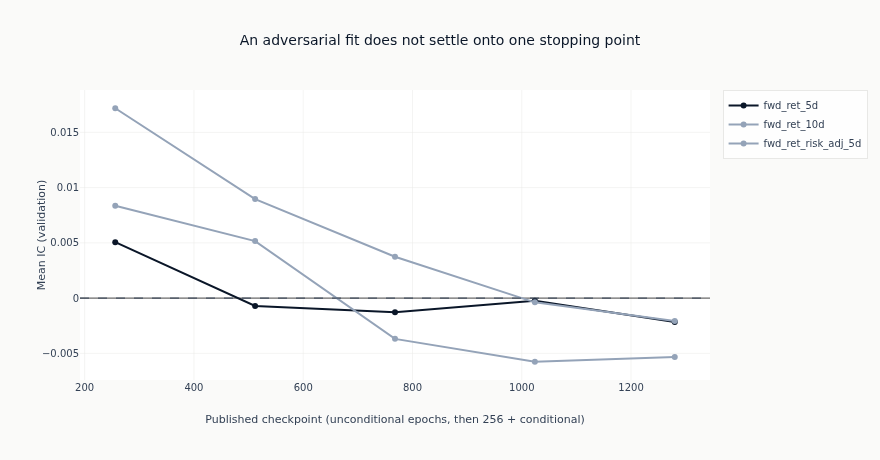

In [12]:
fig = go.Figure()
for label in ordered_labels:
    rows = catalog.filter(pl.col("label") == label).sort("checkpoint_value")
    fig.add_trace(
        go.Scatter(
            x=rows.get_column("checkpoint_value").to_list(),
            y=rows.get_column("ic_mean").to_list(),
            mode="lines+markers",
            name=label,
            line=dict(color=COLORS["blue"] if label == primary else COLORS["recede"]),
            marker=dict(color=COLORS["blue"] if label == primary else COLORS["recede"]),
        )
    )
fig.add_hline(y=0, line_width=1, line_dash="dash", line_color=COLORS["neutral"])
fig.update_yaxes(title_text="Mean IC (validation)")
fig.update_xaxes(title_text="Published checkpoint (unconditional epochs, then 256 + conditional)")
fig.update_layout(
    title="An adversarial fit does not settle onto one stopping point",
    height=460,
    width=880,
    margin=dict(t=90),
)
# The span of each line is a fact about the frame, so the alt text counts it rather than asserting
# a shape the next run may not reproduce.
spans = "; ".join(
    f"{row['label']} spans {row['lo']:+.4f} to {row['hi']:+.4f}"
    for row in catalog.group_by("label")
    .agg(lo=pl.col("ic_mean").min(), hi=pl.col("ic_mean").max())
    .sort("label")
    .iter_rows(named=True)
)
show_plotly_with_alt(
    fig,
    "Line chart of mean validation information coefficient against the published checkpoint number, "
    "one line per label on one axis, the primary target in dark navy "
    f"and the two variants in light slate, with a dashed zero line. Counted from the frame: {spans}.",
)

## 5. What to notice

**This is the one notebook in the family that is not estimating a factor structure**, so its row in
[`13_model_analysis`](13_model_analysis.ipynb) is not comparable with its siblings' in the way
theirs are with each other. PCA, IPCA and the conditional autoencoder differ by one map and
nothing else. This differs in what is being estimated, and the head that turns a discount factor
into a per-stock signal is an extra modelling choice sitting between the estimator and the IC.

**The four states the library chose by reading validation are not in the population, and that is
the point.** An entry whose definition is "the epoch where validation Sharpe was highest", entered
into a contest judged on validation Sharpe, wins by construction - and the number it wins with is
a maximum over many attempts reported as a single result. If it won, that configuration is what
would be replayed on the holdout, which is read once. The schedule that decides what gets
registered is built from the physical epochs alone, so this cannot happen, and the guard in
section 3 fails the catalog rather than trusting that it stayed true.

**The axis those states were packed onto is still a trap, and the sign of `checkpoint_value` is
not a safe test.** Flattening two training phases onto one integer puts one validation-chosen
state on `0` - the same value IPCA legitimately publishes for its single
fit. A `< 0` filter would keep the most dangerous of the four and a `<= 0` filter would throw away
a sibling's only checkpoint. Anything that needs to identify a checkpoint's kind reads the
library's named constants, never the arithmetic.

**An adversarial objective has no single stopping point to find.** Two networks improve against
each other, so a plateau in one is not a plateau in the system, and the epoch chart is where that
shows: a schedule that wanders is what this class of estimator does, not evidence that the fit
failed. That is also why the library offers best-validation states at all, and why using them
needs the caveat above rather than a shrug.

**The macro panel is the only outside information in this family, and it is hashed.** Nothing else
here reads a series that is not the cross-section's own. If the macro panel is rebuilt, this
model's training identity moves and its four siblings' do not, which is worth knowing before
concluding that SDF has drifted relative to them.

**Known limitations.** Two folds, one of them validating on 2020, a year in which the
cross-section co-moved unlike any other in the sample - which bears on a pricing-kernel estimator
at least as much as on a factor model. The factor count, the three budgets and the network shapes
are declared rather than chosen, and nothing here tests whether other settings would order the
cross-section better; that would be a search, and a search over validation IC is what this
notebook is arranged to avoid. The IC carries no adjustment for the serial dependence overlapping
multi-day returns create, so it is a ranking diagnostic rather than a test. Adversarial training
is stochastic and the two networks can trade places between runs, so reproducing the identity does
not reproduce the third decimal place. And nothing in this path makes a convergence determination:
the fit runs its declared budgets and stops, so a run that had not settled would publish looking
exactly like one that had.

**Next**: [`11e_supervised_autoencoder`](11e_supervised_autoencoder.ipynb) returns to the
autoencoder of [`11c`](11c_conditional_autoencoder.ipynb) and adds the one thing every model in
this family has so far been denied - the forward return itself, in the objective.